# Workflow of Wigeon project

This notebook will guide you through the code of the Wigeon multidisplinary analysis design & optimization (MDAO or MADO). The repository of this can be found with this link: https://github.com/dmkeijzer/Wigeon_Montecarlo.git . Along this notebook, references will be made to this repository so one could check where they are relative to the main repository and such gain a higher level understanding. To introduce the user to this process without overloading them with the numerous computations and long run times which the main repository requires some simplifications have to be made. These assumptions will first be clearly be addressed to avoid any misconceptions about how the notebook relates to the main repository. However, first the N2 chart of the main code will be shown so it can be referenced for further use.


## N2 map of main repository

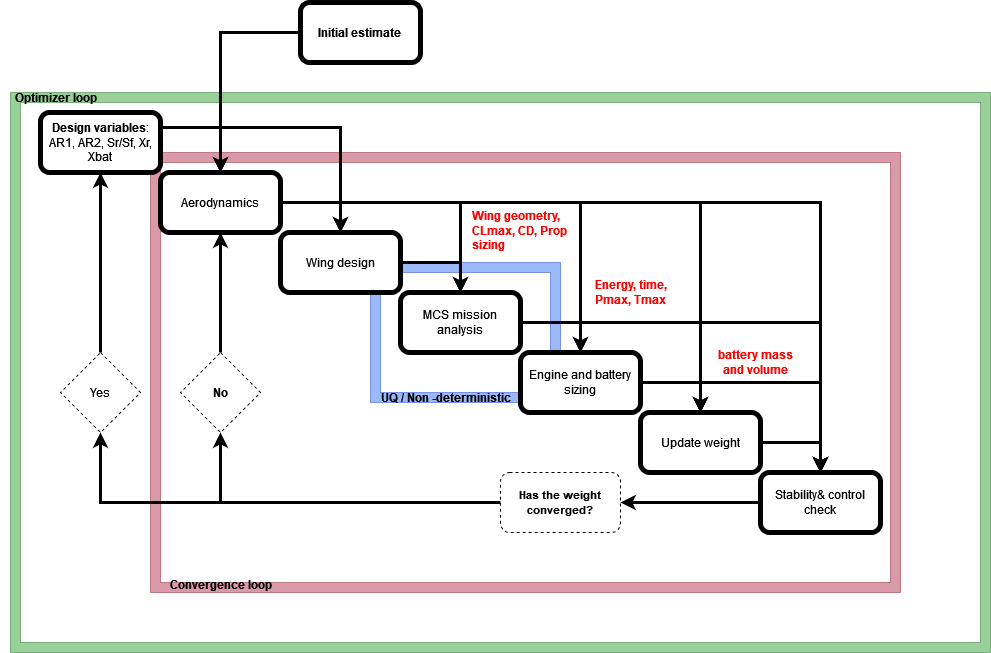

Here above the N2 chart of the main repository can be seen. In this N2 map, the boxes with thick lines represent a subsystem/discipline and the thin-lined boxed represent some action or decision. The first important feature the user should notice is the 3 separate boxes seen in the chart. Each box represents are certain domain of the entire MADO process. From out to in we have: the optimizer loop, convergence loop and the Uncertainty quantificiation (UQ)/ Non-determenistic domain. It is not necessary to understand what this entails at this point, however the user should keep this in mind along the way for a better understanding. A small run through of the chart is explained below.

The entire MADO starts at the initial estimate, this is required to start up the process. Then the first step is computing the wing desgin based on the initial estimate. Then using the wing design, the aerodynamics can be computed. The results of this can then flow down in the rest of the subsystems as shown in the N2 chart. An important system that the information flows into is the MSC mission analysis this is the main difference between the original Wigeon project and the current version based on a reliability based optimization. In this box, the computation and parameters used are no longer deterministic i.e they have no one fixed value but are stochastic based. Specifically, all mission parameters are non-deterministic and are described by a probability density function. In this way an uncertainty quantification is performed on the mission uncertainty. This is especially useful for the rising (long range) VTOL market as it currently is non-existent so a great uncertainty is involved. To be able to perform computations on these non-deterministic parameters they are sampled. Then a Monte Carlo simulation can be performed. 

The output of this subsystem has to be converted into a deterministic parameters again. This is done through a reliability index of 90% i.e the VTOL should be able to fly 90% of all missions. Applying this 90% boundary to the various performance distributions outputted by the mission analysis gives the deterministic parameters required for the rest of the MADO process.

The deterministic parameters obtained are first inputted into the engine and battery sizing. This is one of the most influential subsystems of the entire VTOL as batery weight plays a huge role due to their heavy weight.
    After, the engine and battery sizing the final weight and weight distributions of the Wigeon can be updated. Afterwards a stabiltiy and control check are performed. If the aircraft passed the stability and control it moves on to the next system. 
    
 The process then ends up at a block asking whether the weight has converged. The meaning of this block might be vague to the user at first. This block is necessary due to starting with an initial estimate, this initial estimate contained an estimate on the MTOM of the VTOL. However, in the second to last subsystem the weight was updated as more accurate information was available on the MTOM. Thus, there would be a difference between the starting MTOM and the ending MTOM of this iteration. The design currently going through the MADO process only makes sense when this starting MTOM and ending MTOM have converged to the same weight. To be able to do this, the design must go through a number of the iterations previously described. 
    
Thus, coming back to the block "Has the weight converged?". If the answer is "no" the MADO goes back to the starting point with the newly acquired MTOM and other estimates. The user should note here that the MADO stays within  the convergence loop (the red square). If the answer is "yes", the MADO leaves the convergence loop and enters the optimizer loop where a system optimizer alters the design variables set by the user. The system optimizers uses a cost function based on the energy usage of the VTOL. Thus, it is clear that the energy estimate has a very large influence on where the design ends up. With a general overview of the code, the assumptions for this notebook can be explained.



## Assumptions 

Like mentioned before some parts of the main repository are extremely computationally expensive hence in this notebook these will be simplified such that they can be majorly simplified while stil conveying the right idea. 

1. The first and largest time consumer is the numerical simulation required to compute the energy and time required to complete the transition of the Wigeon eVTOL. This computation happens twice in the flight mission as it needs to be computed right after take off and right before landing. To avoid this issue inside this notebook a major simplification will be made. The energy, time and distance required will be computed using a regression line utilising only the MTOM. This is very crude but serves the purpose for this notebook.



2. The second point concerns the amount of subsystems that are designed  during the MADO. In the original repository all systems/discpines are accounted for in the MADO. However, to avoid needlessy complexifying this notebook some will be simplified or removed in its entireity. It's important to keep in mind that when creating your own MADO you can make the discplines as complicated as you'd like to for increased fidelity but in almost all cases you will pay for it in computational power or runtime. Thus, in this notebook the decision was made to go with a low fidelity to keep the overview clear and understandable. This will lead to some subystems being left out or simplified. See a summary hereunder:

#### Overall
    
* No stability or control check will be performed *This section might be explained in a different notebook*
* Fuselage and structural sizing is left out to keep a clear overview

      
#### Aerodynamics

* Winglet effects are not taken into account
* Constant Oswald's efficiency factor and zero lift drag are assumed
* Majorly simplified drag computation thus not using the drag form factor method. This is to avoid an unnecessary amount of code
* $\frac{d \epsilon}{d \alpha} $, the washdown from the wing, is considered a constant in reality this will be computed based on several wing parameters. See file Wing_design.py in the main repository.
* Wing-fuselage interaction is not taken into account

#### Propulsion 

* The total propulsive efficiency of the drivetrain is assumd to be 0.87
* The battery weight has a power limit and energy limit, in this notebook we'll only check for the energy limit as in reality this is the limiting factor in almost all cases. Except in very high power use cases.

## Constants

These are the constants that will be used throughout this notebook. The user should take a quick glance at these variables but should not feel refrained from coming back when feeling confused about the variables.



In [12]:
import numpy as np



# MADO

c_i = 0.9                   # One sided confidence interval
n_ult = 3.2*1.5             # 3.2 is max found from literature and 1.5 is a safety factor
n_pax = 5


# Physics
g = 9.80665                 # [m/s^2]
gamma = 1.4                 # [-]
R = 287                     # [J/kg/K]
rho_0 = 1.225               # [kg/m^3]

# Mission performance
max_roc = 5                 # [m/s]
max_rod = 4                 # [m/s]

# Fuselage
w_fuselage = 1.38           # [m]
h_fuselage = 1.7            # [m]
l_nosecone = 2.5            # [m]
l_cylinder = 2              # [m]
l_tailcone = 2.7            # [m]
l_fuselage = l_tailcone + l_cylinder + l_nosecone # [m]
per_fuselage = 17           # [m] Perimeter of fuselage in a top down view
# upsweep = 8.43*np.pi/180    # [Degrees]

# Aerodynamics
s1 = 0.5                    # Fraction of total wing area for the 1st wing [-]
s2 = 1-s1                   # Fraction of total wing area for the 2nd wing [-]
sweepc41 = 0                # Sweep angle at quarter chord for 1st wing [rad]
sweepc42 = 0                # Sweep angle at quarter chord for the 2nd wing
cd0 = 0.02                  # Zero lift drag of the entire planform
e = 0.8                     # Oswald's efficiency factor
deda = 0.25                 # Downwash per radian [-]

# Propulsion
xi_0 = 0.1                  # Dimensionles radius of the hub
eff_prop = 0.83             # [-] Propeller efficiency during normal flight 
eff_hover = 0.88            # [-] Propeller efficiency during hover 
c_fp = 0.3                  # Horizon clearance between the widest part of the fuselage adn the radius of the inboard pro
c_p = 0.3                   # Horizontal clearne between the propellers
n_prop_fr = 6               # Number of propellors on the front wing  
n_prop_rear =6              # Number of proellors on the rear wing

# Battery and power
sp_en_den = 500          # [Wh/kg] Specific energy density
sp_mass_en = 1/5000      # kg/w
vol_en_den = 900         # [Wh/l] Volumetric energy density
bat_cost = 100           # [$/kWh] Cost of batteries in US dollars per kilogram
DoD = 0.8                # [-] Depth of Discharge of the total battery
P_den = 6500             # [W/kg] Power density of battery
EOL_C = 0.85             # [-] Fraction of initial capacity that is available at end-of-life
eff_bat_eng_cr = 0.9     # Efficiency from the battery to the engines (including both) in cruise
eff_bat_eng_h = 0.75     # Efficiency from the battery to the engines (including both) in hover

#airfoil characteristics

clmax = 1.78                # Maximum lif coefficient
a_max_lift = 18             # Maximum lift angle in degrees
cdmin = 0.006               # Mimimum drag coefficient
cl_cdmin = 0.7              # Cl/cd minimum value
cm   = -0.0067              # Moment coefficient around the aerodynamic chord (remains constant)
clalpha = 0.105             # Increase in lift coefficient per degree
clcdmax = 156               # Maximum lift over drag ratio of the airfoil
a_zero_lift = -3.3          # Zero lift angle of the airfoil



## ISA computation

At many points during the integration and optimization it is required to compute the atmospheric values at a certain altitude. Hence, a class is created to keep the lines of code in the main code to a minimum.

In [13]:

class ISA:
    """
    Calculates the atmospheric parameters at a specified altitude h (in meters).
    An offset in sea level temperature can be specified to allow for variations.

    Note: Since our aircraft probably doesn't fly too high, this is only valid in the troposphere

    Verified by comparison to: https://www.digitaldutch.com/atmoscalc/
    """

    def __init__(self, h, T_offset=0):

        # Constants
        self.a = -0.0065    # [K/m]     Temperature lapse rate
        self.g0 = 9.80665   # [m/s^2]   Gravitational acceleration
        self.R = 287        # [J/kg K]  Specific gas constant
        self.gamma = 1.4    # [-]       Heat capacity ratio

        # Sea level values
        self.rho_SL = 1.225                                 # [kg/m^3]  Sea level density
        self.p_SL   = 101325                                # [Pa]      Sea level pressure
        self.T_SL   = 288.15 + T_offset                     # [K]       Sea level temperature
        self.mu_SL  = 1.7894E-5                             # [kg/m/s] Sea Level Dynamic Viscosity 1.81206E-5
        self.a_SL   = np.sqrt(self.gamma*self.R*self.T_SL)  # [m/s] Sea level speed of sound

        self.h = h  # [m]       Altitude

        # Throw an error if the specified altitude is outside of the troposphere
        if np.any(h) > 11000:
            raise ValueError('The specified altitude is outside the range of this class')

        self.T = self.T_SL + self.a * self.h  # [K] Temperature at altitude h, done here because it is used everywhere

    def temperature(self): return self.T

    def pressure(self): return self.p_SL * (self.T / self.T_SL) ** (-self.g0 / (self.a * self.R))

    def density(self): return self.rho_SL * (self.T / self.T_SL) ** (-self.g0 / (self.a * self.R) - 1)

    def soundspeed(self): return self.a_SL * np.sqrt(self.T/self.T_SL)

    def viscosity_dyn(self): return self.mu_SL * (self.T / self.T_SL) ** (1.5) * (self.T_SL + 110.4) / (self.T + 110.4) # 1.458E-6 * self.T ** 1.5 / (self.T + 110.4) # Sutherland Law, using Sutherland's constant S_mu = 110.4 for air



# Creating the subsystems

From this point forward, all necessary subsystems/disciplines are created in the form of classes or functions. Thus creating each block in the N2 chart. When all these discplines are created, they can be cascaded together creating the convergence and optimizer loop. In this process, all displines must be linked together in a logical and correct manner.

### Wing design and lift/drag characteristics of the planform

In [14]:

class wing_design:

    def __init__(self, AR1, AR2, s1, sweepc41, s2, sweepc42, M, S, i1):
        """This class allows the user to easily compute the planform geometry and also offers some functions
        to compute the lift characteristics of the planform.

        :param AR1: Aspect ratio of the front wing
        :type AR1: Float
        :param AR2: Aspect ratio of the back wing
        :type AR2: Float
        :param s1: Fraction of front wing area w.r.t total area i.e  Sf/(sf + sr)
        :type s1: Float
        :param sweepc41: Quarter chord sweeep angle of the front wing in degrees
        :type sweepc41: Float
        :param s2: Fraction of front wing area w.r.t total area i.e Sr/(sf + sr)
        :type s2: float
        :param sweepc42: Quarter chord sweep angle of the rear wing in degrees
        :type sweepc42: Float
        :param M: Mach number 
        :type M: float
        :param S: Total surface area of the front and rear wing in m^1
        :type S:  float
        :type k_wl: float
        :param i1: Trim angle for the first wing should be
        :type i1: float
        """        
        
        self.AR1 = AR1
        self.AR2 = AR2
        self.s1 = s1
        self.S1 = s1 * S
        self.sweepc41 = sweepc41
        self.s2 = s2
        self.S2 = s2 *S
        self.sweepc42= sweepc42
        self.clmax = clmax
        self.Cl_Cdmin = cdmin
        self.Clalpha = 0.105
        self.a_0L = a_zero_lift
        self.a_saf = a_max_lift
        self.M = M
        self.S = S
        self.i1 = i1  # trim angle for first wing

    def taper_opt(self):
        return 0.45 * np.exp(-0.036 * self.sweepc41), 0.45 * np.exp(-0.036 * self.sweepc42)  # Eq. 7.4 Conceptual Design of a Medium Range Box Wing Aircraft

    def wing_planform_double(self):
        # Wing 1
        self.taper1 = self.taper_opt()[0]
        self.taper2 = self.taper_opt()[1]
        b1 = np.sqrt( self.AR1 * self.S1)
        c_r1 = 2 * self.S1 / ((1 + self.taper1) * b1)
        c_t1 = self.taper1 * c_r1
        c_MAC1 = (2 / 3) * c_r1 * ((1 + self.taper1 + self.taper1 ** 2) / (1 + self.taper1))
        y_MAC1 = (b1 / 6) * ((1 + 2 * self.taper1) / (1 + self.taper1))
        tan_sweep_LE1 = 0.25 * (2 * c_r1 / b1) * (1 - self.taper1) + np.tan(self.sweepc41)
        X_LEMAC1 = y_MAC1 * tan_sweep_LE1

        wing1 = [b1, c_r1, c_t1, c_MAC1, y_MAC1, X_LEMAC1]

        b2 = np.sqrt( self.AR2 * self.S2)
        c_r2 = 2 * self.S2 / ((1 + self.taper2) * b2)
        c_t2 = self.taper2 * c_r2
        c_MAC2 = (2 / 3) * c_r2 * ((1 + self.taper2 + self.taper2 ** 2) / (1 + self.taper2))
        y_MAC2 = (b2 / 6) * ((1 + 2 * self.taper2) / (1 + self.taper2))
        tan_sweep_LE2 = 0.25 * (2 * c_r2 / b2) * (1 - self.taper2) + np.tan(self.sweepc42)
        X_LEMAC2 = y_MAC2 * tan_sweep_LE2

        wing2 = [b2, c_r2, c_t2, c_MAC2, y_MAC2, X_LEMAC2]
        return wing1, wing2

    def sweep_atx(self, x):
        wg = self.wing_planform_double()
        b1 = wg[0][0]
        c_r1 =  wg[0][1]
        b2 = wg[1][0]
        c_r2 = wg[1][1]
        tan_sweep_LE1 = 0.25 * (2 * c_r1 / b1) * (1 - self.taper1) + np.tan(self.sweepc41)
        sweep1 = np.arctan(tan_sweep_LE1- x * (2 * c_r1 / b1) * (1 - self.taper1))
        tan_sweep_LE2 = 0.25 * (2 * c_r2 / b2) * (1 - self.taper2) + np.tan(self.sweepc42)
        sweep2 = np.arctan(tan_sweep_LE2 - x * (2 * c_r2 / b2) * (1 - self.taper2))
        return sweep1, sweep2

    def liftslope(self):
        beta = np.sqrt(1 - self.M ** 2)
        SW = np.tan(self.sweep_atx(0.5))
        wg = self.wing_planform_double()

        self.AR_i = self.AR1 
        slope1 = self.Clalpha * (self.AR_i / (2 + np.sqrt(4 + ((self.AR_i * beta / 0.95) ** 2) * ((1 + SW ** 2) / (beta ** 2)))))
        self.AR_2 = self.AR2 
        slope2_b = self.Clalpha * (self.AR_2 / (2 + np.sqrt(4 + ((self.AR_2 * beta / 0.95) ** 2) * ((1 + SW ** 2) / (beta ** 2)))))
        slope2 = slope2_b * (1 - deda)

        slope_tot = (slope1 * self.s1 + slope2 * self.s2)
        return slope_tot, slope1, slope2_b, deda, slope2, slope1, slope2

    def CLmax_s(self):
        ls = self.liftslope()
        CLa = ls[0]
        deda = ls[3]
        CLmax1 = self.clmax *0.9
        alpha_s2 = np.round(((self.a_saf-self.i1 -self.a_0L)*(1-deda) +self.a_0L)*4)/4
        CLmax2 = 0.9* 1.3082 #simplification from original code in repostiory
        CLmax = self.s1*CLmax1 +self.s2*CLmax2
        self.a_s = (180/np.pi)* CLmax/CLa + self.a_0L
        return CLmax, CLmax1, CLmax2, self.a_s
    
# drag during horizontal configuration

def drag_planform(cL, AR):
    """Compute the drag for a given cL and and aspect ratio
    
    - cd0 and e is assumed constant for the sake of this analysis
    """
    return cd0 + 1/(np.pi*AR*e)*cL**2
wingdesign =  wing_design(10, 10, (1 + 1.1)**-1, 5, (1 + 1.1)**-1*1.1, 5, 0.3, 20, 5) # test entry and  examples of each function
print(wingdesign.wing_planform_double())
print(wingdesign.taper_opt())
print(wingdesign.sweep_atx(0.3))
print(wingdesign.liftslope())
print(wingdesign.CLmax_s())



([9.759000729485331, 1.4185917877790435, 0.5332083581180231, 1.042838604809849, 2.0708404200125745, -6.906568819652192], [10.23532631438318, 1.4878316189641745, 0.5592336439124616, 1.0937383559379856, 2.171915755657581, -7.243670488547299])
(0.3758715951350724, 0.3758715951350724)
(-1.283913520159108, -1.283913520159108)
(array([0.02303132, 0.02303132]), array([0.02650179, 0.02650179]), array([0.02650179, 0.02650179]), 0.25, array([0.01987634, 0.01987634]), array([0.02650179, 0.02650179]), array([0.01987634, 0.01987634]))
(1.3795800000000003, 1.602, 1.17738, array([3428.72713975, 3428.72713975]))


### Propellor sizing and drag characteristics

In this section a function and class will be loaded in which allows the user to size the propellers based on momentum theory and compute the drag of the aircraft on a very simple drag polar. Do not worry about understanding all the equations in the prop sizing class however if the user is interested they are encouraged to read the paper published by the original DSE team.

In [15]:
class PropSizing:
    def __init__(self, wing_span, fuselage_width, N_eng, clearance_fus_prop, clearance_prop_prop, MTOM, xi_0):
        """
        :param wing_span: FUll span of one wing (TIP TO TIP) [m]
        :param fuselage_width: Width of the WHOLE fuselage (not half) [m]
        :param N_eng: Number of propellers in total [-]
        :param clearance_fus_prop: horizontal distance between propeller and fuselage [m]
        :param clearance_prop_prop: Horizontal distance between propeller and propeller
        :param MTOM: Maximum take-off mass [kg]
        :param xi_0: Hub radius ratio (r_hub/R)
        """
        self.b = wing_span
        self.wf = fuselage_width
        self.N_tot = N_eng
        self.N_per_half_wing = N_eng/4
        self.c_fp = clearance_fus_prop
        self.c_pp = clearance_prop_prop
        self.MTOM = MTOM
        self.xi_0 = xi_0

    def radius(self):
        """
        Size the radius based on the span, assuming one tip mounted engine
        """
        return (self.b/2 - self.wf/2 - self.c_fp - (self.N_per_half_wing - 1)*self.c_pp) / \
               (2*self.N_per_half_wing - 1)  # (2*(self.N_per_half_wing - 1) + 1)

    def diameter(self):
        return 2*self.radius()

    def area_prop(self):
        return np.pi*(self.radius()**2 - (self.xi_0*self.radius())**2)

    def disk_loading(self):
        """
        Calculate disk loading in hover based on propeller area and MTOM
        Calculate total area and divide mass by that

        :return: Disk loading in kg/m^2
        """
        area_prop = np.pi*(self.radius()**2 - (self.xi_0*self.radius())**2)
        area_tot = self.N_tot*area_prop
        return self.MTOM/area_tot
    

prop = PropSizing(8, 3, 8, 0.3, 0.3, 2000, 0.1)
print(prop.radius())
print(prop.area_prop())
print(prop.disk_loading())


0.6333333333333334
1.247526442740507
200.39655388050278


### Determing optimum speeds

To be able to judge the performance of the VTOL, the optimum speeds must first be computed for the airframe at a certain altitude. This can be done with the code shown below. 

In [16]:
class speeds:
    """
    Class that contains all the relevant speeds.
    """
    def __init__(self, altitude, mtom, CLmax, S, ar):

        # To be added from datafile:
        self.CLmax  = CLmax
        self.S      = S
        self.rho    = 1.225 * ((288.15 + -0.0065*altitude)/288.15)**(g/(-0.0065*287))
        self.W      = mtom*g
        self.CL = np.linspace(0, self.CLmax, 1000)
        self.CD = np.vectorize(drag_planform)(self.CL, ar)

    def stall(self): return max(np.sqrt(2*self.W/(self.rho*self.S*self.CLmax)), 40)

    def climb(self):
        """
        Climb speed, note that this is only a first order estimate, and should not be used when the climb angle is steep
        For steep climb angles, the required CL is less, and the maximum rate-of-climb will be at a different speed.
        """        
        CL3CD2 = (self.CL**3)/(self.CD**2)
        idx = np.argmax(CL3CD2)
        CL_climb = self.CL[idx]
        V_climb  = np.sqrt(2*self.W/(self.rho*self.S*CL_climb))
        return V_climb

    def endurance(self):
        
        CL_CD_opt = (self.CL**(3/2))/(self.CD)
        idx = np.argmax(CL_CD_opt)
        CL_climb = self.CL[idx]
        v_endurance  = np.sqrt(2*self.W/(self.rho*self.S*CL_climb))
        return v_endurance

    def cruise(self):
        CLCD    = self.CL/self.CD
        idx     = np.argmax(CLCD)
        CL_cr   = self.CL[idx]
        V_cr    = np.sqrt(2 * self.W / (self.rho * self.S * CL_cr))

        return V_cr, CL_cr


v = speeds(1000, 2000, 1.7, 20, 7.3)
print(v.stall())
print(v.climb())
print(v.endurance())
print(v.cruise())

40
36.777168127652835
36.777168127652835
(48.41677612606316, 0.6058058058058058)


### MCS based performance analysis

To perform the MCS based performance analysis as efficiently as possible, the code should preferably handle all the samples concurrently rather than sequentially. An easy and quick way to do this in python (when possible) is to use the multiprocessing library, specificaly the multiprocessing.Pool class. To be able to leverage it's starmap method a function has to be created which handles one specific sample from the sampling space. Hence, the function name will be `single_sample_msc` which will be part of a larger class as this more practical as we can easily string together methods and attributes that will be required by the simplified simulation.  However, remember from the assumptions that some simplificatons would be made with respect to the transition. First, a small explanation on the new mission profile

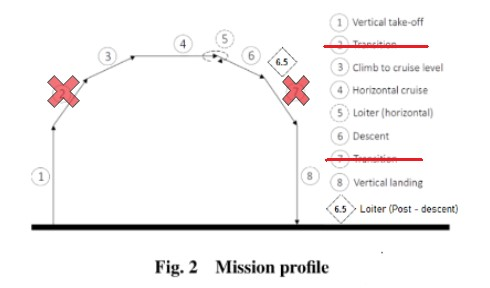

As seen above the transition are removed from the mission profile. These will now be determined by a regression which is based of data outputted by the main repository. This will be in the form of a basic linear mulitvariate regression. The parameters chosen for this are the aspect ratio's of both the front and rear wing and the wing loading of the aircraft. This is a very crude approximation which should <font size = 3> **not** </font>  be used for any other purposes than illustrating the workflow of this repository. Three functions are replacing the transition, one for the energy used during climb, one for the energy during descend and one function to compute the time for both descend and climb. The reason for this is due to the way it was extracted from the output of the main repository.

* Note that there is no real simulation taking place anymore, just a simplified energy computation. In the actual repository a simulation is used but this was avoided due to the added computational time and complexity

In [17]:
def E_transition_climb(w_s, ar1, ar2):
    coef = [  -182271.80476409, -11162378.54796697, -15119948.42198241]
    intercept = 567103409.1983494
    return np.dot(coef, [w_s, ar1, ar2]) + intercept



def E_transition_desc(w_s, ar1, ar2):
    coef = [  -55408.73973574, -5877766.44625907, -9081890.05926067]
    intercept = 262959149.71210575
    return np.dot(coef, [w_s, ar1, ar2]) + intercept

def time_climb_desc(w_s, ar1, ar2):
    coef = [   0.44959022, -181.61537263,   14.69915226]
    intercept = 1186.562739606004
    return np.dot(coef, [w_s, ar1, ar2]) + intercept


class MCS:

    def __init__(self,  w_s, ar1, ar2, mtom, s1, s2, cLmax,  v_cruise, hcruise , area_prop):
        """ Class which sets up the framework for computing the energy used during a range of
        mission

        :param ar1: Aspect ratio of the front wing
        :type ar1: float [-]
        :param ar2: Aspct ratio of the rear wing
        :type ar2: float [-]
        :param mtom: Maximum take off weight
        :type mtom: float [kg]
        :param s1: Wing aera of the front wing
        :type s1: float [m^2]
        :param s2: Wing area of the rear wing
        :type s2: float [m^2]
        :param cLmax: Maximum lift coefficient
        :type cLmax: float [-]
        :param v_cruise: Velocity during the cruise phase
        :type v_cruise: float [m/s]
        :param hcruise: Altitude at which the eVTOL cruises
        :type hcruise: float [m]
        :param area_prop: Total propeller area
        :type area_prop: float [m^2]
        """        
        self.E_climb = E_transition_climb(w_s,ar1, ar2)
        self.E_desc = E_transition_desc(w_s, ar1, ar2)
        self.t_climb_desc = time_climb_desc(w_s, ar1, ar2)
        self.ar1 = ar1
        self.ar2 = ar2
        self.v_cr = v_cruise
        self.mtom = mtom
        self.s_tot = s1 + s2
        self.s1 = s1
        self.s2 = s2
        self.hcruise = hcruise
        self.area_prop = area_prop
        self.cLmax = cLmax
        self.Aeff = self.ar1 * self.s1/self.s_tot + self.ar2 * self.s2/self.s_tot

    def thrust_to_power(self, T, V, rho):
            """
            This function calculates the available power associated with a certain thrust level. Note that this power
            still needs to be converted to brake power later on. This will be implemented when more is known about this
            from the power and propulsion department

            :param T: Thrust provided by the engines [N]
            :param V: Airspeed [m/s]
            :return: P_a: available power
            """

            P_a = T * V + 1.2 * T * (-V / 2 + np.sqrt(V ** 2 / 4 + T / (2 * rho * self.area_prop)))
            P_r = P_a/0.87 # Assumption made at the start of the notebook

            return P_a, P_r

    def power_cruise_config(self, altitude, speed, mass):

        # Density at cruising altitude
        # rho = 1.225 * ((288.15 + -0.0065*altitude)/288.15)**(g/(-0.0065*287))
        rho = ISA(altitude).density()

        # Lift coefficient during cruise, based on the cruise speed (can be non-optimal)
        CL_cruise = 2 * mass * g / (speed * speed * self.s_tot * rho)
        # Drag coefficient
        CD_cruise = drag_planform(CL_cruise, self.Aeff) 
        D_cruise = CD_cruise*0.5*rho*speed*speed*self.s_tot
        P = self.thrust_to_power(D_cruise, speed, rho)[1]
        return P, D_cruise
    
    def single_sample_monte_carlo(self, d_total, t_loit_cruise, h_trans, h_loiter_cruise, t_loit_hover):
        """Computes the main mission metrics for a fixed mission based on the inputs

        :param d_total: Total distance travelled, or cruise in this simplified version
        :type d_total: float [m]
        :param t_loit_cruise: Time spent loitering in cruise configuration [s]
        :type t_loit_cruise: flotat [s]
        :param h_trans: Transition height of eVTOL 
        :type h_trans: float [m]
        :param h_loiter_cruise: Height at which the eVTOL loiters in cruise configuration
        :type h_loiter_cruise: float [m]
        :param t_loit_hover: Time spent loiterin in hover configuration 
        :type t_loit_hover: float [s]
        :return: A tuple of the total energy, total time, time spent in cruise configuration and the enrgy distribution
        across the different flight phases
        :rtype: tuple
        """        
        # Distance spent in cruise
        d_cruise = d_total 
        # Time spent cruising
        t_cruise = d_cruise / self.v_cr

        # Get the brake power used in cruise
        P_cruise, D_cruise = self.power_cruise_config(self.hcruise, self.v_cr, self.mtom)  
        V = speeds(self.hcruise, self.mtom, self.cLmax, self.s_tot, self.Aeff )

        # Loiter power
        V_loit = V.endurance()
        P_loiter, _ = self.power_cruise_config(altitude= h_loiter_cruise, speed=V_loit, mass=self.mtom)  

        # Cruise energy
        E_cruise = P_cruise * t_cruise
        # Loiter energy cruise and hover
        E_loiter_cruise = P_loiter * t_loit_cruise
        E_loiter_hover = self.thrust_to_power(self.mtom*9.81, 0, 1.225)[1] * t_loit_hover
        E_loiter = E_loiter_cruise + E_loiter_hover

        # Get the total energy consumption
        E_tot = E_cruise + self.E_climb + self.E_desc + E_loiter

        t_tot = self.t_climb_desc + t_cruise + t_loit_hover + t_loit_cruise
        t_cruise_config = t_cruise + t_loit_cruise

        energy_dist = np.array([E_cruise, self.E_climb, self.E_desc, E_loiter_cruise, E_loiter_hover])
        return E_tot, t_tot,  t_cruise_config, energy_dist

sim = MCS(1450, 7,7, 2000, 10, 12, 1.7, 70, 1000, 1.3)
print(sim.E_climb)
print(sim.E_desc)
print(sim.t_climb_desc)
print(sim.single_sample_monte_carlo(3e5, 600, 150, 200, 20 ))

118833003.50077319
77898881.55664456
670.055016016004
(898880756.103019, 5575.769301730289, 4885.714285714285, array([6.03949670e+08, 1.18833004e+08, 7.78988816e+07, 5.57190768e+07,
       4.24801240e+07]))


### Modelling mission uncertainty

As mentioned previously, the function we've created only provides it for a single sample. Thus, in the following block of code we'll create a function that can easily sample the distributions we have defined. To do that we first need distributions to sample from, we need to find them for the following variables:

* distance traveled  $=d_{total}$
* loitering time in cruise configuration  $=t_{loit,cr}$
* loitering time in hover configuration  $=t_{loit,hvr} = 1.4 * \frac{h_{trans}}{Rate \ of \ descend} \cdot Ber(0.01)$
* transition height  $=h_{trans}$
* The height at which we loiter in cruise configuration  $=h_{loit,cr} = 1.2 \cdot h_{trans}$

As can be seen above we only need to define four distributions as $h_{loit,cr}$ is defined from $h_{trans}$. These distributions and their visualizations can be seen in the following block of code, where  the function to extract samples from them is also defined. Also, notice that loiteirng time in hover configuration is a combination of a discrete and continuous random variable hence it is portrayed using a histogram with a sufficiently large sampling space. Finally, the visible bins in the histogram of $t_{loit,hvr}$ do not add up to 1, this is because the remainder are all in the bins at 0 $[s]$. This bin was not included for clarity of the graph.


In the integration code, we must easily be able to sample from these distributions. The implementation of this sampling can be found in the function  `def sampling:`. The only difference with the plotted distributions is that the distribution for the mission distance is clipped to a minimum value as it is not realistic for a long range eVTOL to fly missions below a certain set range. Then, all the mission samples are all combined into an array where each row represent one mission description. This specific form is chosen as this is required for the use of the starmap function used in the main integration code. Thus, the form of the array is as shown below where the subscript represents the $n_{th}$ mission sample: 

$$

\begin{bmatrix}
d_{total_1} & t_{loit,cr_1} & h_{trans_1} & h_{loit,cr_1} & t_{loit,hvr_1} \\
d_{tota_2} & t_{loit,cr_2} & h_{trans_2} & h_{loit,cr_2} & t_{loit,hvr_2} \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
d_{tota_n} & t_{loit,cr_n} & h_{trans_n} & h_{loit,cr_n} & t_{loit,hvr_n} 
\end{bmatrix}

$$



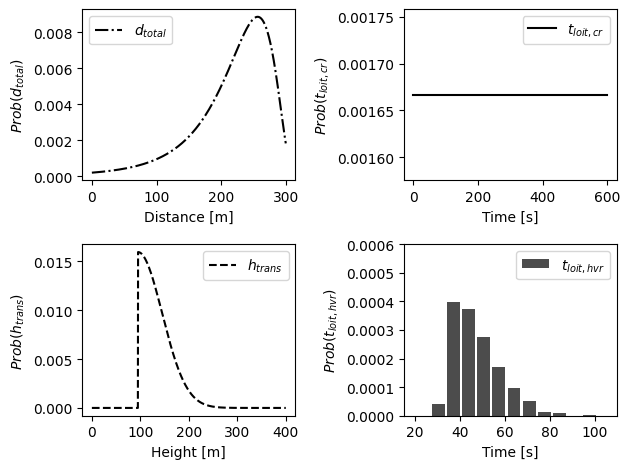

[[2.66182467e+05 7.09451749e+00 1.82620939e+02 2.19145126e+02
  0.00000000e+00]
 [1.62189845e+05 1.82323685e+02 1.43922264e+02 1.72706716e+02
  0.00000000e+00]
 [2.82701634e+05 2.97616620e+02 1.79399053e+02 2.15278863e+02
  0.00000000e+00]
 [1.38292511e+05 2.96147019e+02 2.49184409e+02 2.99021291e+02
  0.00000000e+00]
 [2.25235141e+05 3.45939512e+02 1.29607859e+02 1.55529431e+02
  0.00000000e+00]
 [2.86966063e+05 1.58355536e+02 9.63831219e+01 1.15659746e+02
  0.00000000e+00]
 [2.46611440e+05 2.57089251e+02 1.16462206e+02 1.39754647e+02
  0.00000000e+00]
 [2.72342470e+05 1.57993125e+02 1.04000480e+02 1.24800577e+02
  0.00000000e+00]
 [2.51282326e+05 3.17686873e+02 1.44907957e+02 1.73889548e+02
  0.00000000e+00]
 [2.30912656e+05 4.47758492e+01 1.34738392e+02 1.61686071e+02
  0.00000000e+00]]


In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stat

#-------------------------Visualizing the distributions--------------------------------------------------

fig, axs = plt.subplots(2,2)

x = np.linspace(0,300,1000)
axs[0,0].plot(x, stat.johnsonsu.pdf(x, a= 7.269227185957687, b=1.7901311660080905,  loc= 325.4418832472252, scale=3.2488917030239155), "k-.", label=r"$d_{total}$")
axs[0,0].set_xlabel("Distance [m]")
axs[0,0].set_ylabel(r"$Prob(d_{total})$")
axs[0,0].legend()

x = np.linspace(0,600,1000)
axs[0,1].plot(x, stat.uniform.pdf(x, scale= 600), "k", label= r"$t_{loit,cr}$")
axs[0,1].set_xlabel("Time [s]")
axs[0,1].set_ylabel(r"$Prob(t_{loit,cr})$")
axs[0,1].legend()

x = np.linspace(0,400,1000)
axs[1,0].plot(x, stat.halfnorm.pdf(x, loc= 95, scale= 50), "k--", label= r"$h_{trans}$")
axs[1,0].set_xlabel("Height [m]")
axs[1,0].set_ylabel(r"$Prob(h_{trans})$")
axs[1,0].legend()

h_trans = stat.halfnorm.rvs(loc=95, scale=50, size= int(1e5)) # sampling the h-trans distribution with 1e5 samples
hist_data = 1.4*h_trans/4* stat.bernoulli.rvs(0.01, size= int(1e5)) # Sampling the Bernoulli distribtuion and doing the computation 
axs[1,1].hist(hist_data, color= "k", alpha= 0.7, bins= 15, rwidth = 0.85, density= True, label= r"$t_{loit,hvr}$")
axs[1,1].set_xlabel("Time [s]")
axs[1,1].set_ylabel(r"$Prob(t_{loit,hvr})$")
axs[1,1].set_xlim([15,110])
axs[1,1].set_ylim([0,0.0006])
axs[1,1].legend()

fig.tight_layout()
plt.show()


#--------------------------Creating a sampling function ----------------------------------------------

def sampling(n_samples):
    min_mission_dist = 100 # Minimin mission distance since flying very short mission is unrealistic
    dist_samples = np.array( stat.johnsonsu.rvs(size= n_samples, a= 7.269227185957687, b=1.7901311660080905,  loc= 325.4418832472252, scale=3.2488917030239155))

    # Resample all values below the minimum mission distance
    while np.size(dist_samples[dist_samples < min_mission_dist]) != 0:
        n_resample = np.size(dist_samples[dist_samples <min_mission_dist])
        dist_samples[dist_samples < min_mission_dist ] = stat.genextreme.rvs(0.94,loc=309.40,scale=84.96, size = n_resample)
        
    h_trans_stoch = stat.halfnorm.rvs(loc=95, scale=50, size= n_samples)

    sim_samples = np.column_stack((dist_samples*1000,
                                stat.uniform.rvs(scale=600, size= n_samples) ,
                                h_trans_stoch ,
                                1.2 * h_trans_stoch , 
                                1.4 * h_trans_stoch/4* stat.bernoulli.rvs(0.01, size= n_samples)))
    return sim_samples

print(sampling(10))


### Random Variable class

When performing the Monte Carlo simulation, large amount of data is created from the different mission samples. To be able, to extract the right confidence level and have an accessible visualization for the data a class called `RandVar` will be created. It's input will be raw data, which then will be iteratively fitted with different probability density function and the best fitting one will be returned. Besides creating a distribution, it also offers a plotting and point percent function to be able to extract the confidence level.

In [19]:

import numpy as np
from scipy.stats import loggamma
import multiprocessing as mp
import matplotlib.pyplot as plt

class RandVar():
    def __init__(self, data):
        self.min = np.min(data)
        self.max = np.max(data)
        self.best_fit = loggamma
        self.params = loggamma.fit(data)
        self.arg = self.params[:-2]
        self.loc = self.params[-2]
        self.scale =  self.params[-1]

        if (np.size(data[data == 0]) > (0.5*np.size(data))):
            self.data = data
        else:
            self.data = np.histogram(data, bins= "auto")
    
    def ppf(self, r=0.9):
        return self.best_fit.ppf(r, loc= self.loc, scale = self.scale, *self.arg)

    def plt(self):
        x = np.linspace(self.min, self.max ,  1000)
        pdf = self.best_fit.pdf(x, loc= self.loc, scale= self.scale, *self.arg)
        cdf = self.best_fit.cdf(x, loc= self.loc, scale= self.scale, *self.arg)
        return x,pdf, cdf

### Engine and battery sizing

Now that we're able to estimate the energy  and can create the necessary samples we can start sizing the most defining compoonent of the eVTOL, the battery and engine weight. Like mentioned in the assumptions the battery can be both eneryg and pwoer limited however in this notebook only the energy limit is accounted for. The reasoning for this is explained in the assumptions.




In [20]:
class Power:
    """This class is to estimate the parameters of a battery"""
    def __init__(self,  sp_en_den,  mtom, tot_energy,  DoD,  safety, EOL_C):
        """
        :param sp_en_den: Specific energy density of the battery [Wh/kg]
        :param vol_en_den: Volumetric energy density of the battery [Wh/l]
        :param tot_energy: Required total energy for the battery [Wh]
        :param DoD: Max depth of discharge for the battery [-], af fraction (so range 0 - 1)
        :param safety: Safety factor for all additional components [-]
        :param EOL_C: Required fraction of initial capacity that is required at EOL (end of life) [-]
        """
        self.sp_en_den = sp_en_den
        self.mtom = mtom
        self.energy = tot_energy if tot_energy < 1e6 else tot_energy/3.6e3 # automatically change it to [Wh] if filled in with [J]
        self.DoD = DoD
        self.safety = safety
        self.EOL_C = EOL_C

    def bat_mass(self):
        m_en = self.energy / self.sp_en_den
        return m_en/ (self.DoD * self.EOL_C) * self.safety

    def total_engine_mass(self, sp_mass_en, max_roc, n_engines):
        """Computes the total engine mass, max power is assumed to be the case when the eVTOL is acending with it's maximum rate of climb 
        including a safety factor of 1.4 for any unforeseen emergencies.

        :param sp_mass_en: Specific mass of the engine  i.e kg/w so the amount of weight per watt of power
        :type sp_mass_en: float
        :param max_roc: Maximum climb rate required in hover configuration of the eVTOL
        :type max_roc: flaot
        :param n_engines: The number of engines on the eVTOL
        :type n_engines: int
        :return: A tuple containing the total amount of mass of the engines and the mass per eninge
        :rtype: float
        """    
        pmax_tot =  self.mtom*g*max_roc*self.safety 
        m_prop_tot = pmax_tot*sp_mass_en
        m_prop_perengine = m_prop_tot/n_engines
        return m_prop_tot, m_prop_perengine


power = Power(sp_en_den,2000,  180*3.6e6, DoD, 1.4, EOL_C )
print(power.bat_mass())
print(power.total_engine_mass(0.005, 5, 8))


741.1764705882352
(686.4655, 85.8081875)


### Updating the weight



Now, that all subsystems can be updated through a function or class, the final part of the process is to update the weight of the eVTOL. In the main repository this would also be the subsystem where the center of gravity of the eVTOL would be computed. However, since in this notebook no control and stability analysis is performed this will not be required.

In [21]:

class Wing:
    # Roskam method (not accurate because does not take into account density of material but good enough for comparison
    def __init__(self, mtom, S1, S2, n_ult, AR1, AR2, wmac = 0.8, toc = 0.17):
        self.S1_ft, self.S2_ft, self.S1, self.S2 = S1 * 3.28084 ** 2, S2 * 3.28084 ** 2, S1, S2
        self.n_ult = n_ult
        self.A_1, self.A_2 = AR1, AR2
        self.mtow_lbs = 2.20462 * mtom
        self.wweight1 = 0.04674*((self.mtow_lbs/2)**0.397)*(self.S1_ft**0.36)*(self.n_ult**0.397)*(self.A_1**1.712)*0.453592
        self.wweight2 = 0.04674*((self.mtow_lbs/2)**0.397)*(self.S2_ft**0.36)*(self.n_ult**0.397)*(self.A_2**1.712)*0.453592
        self.mass = self.wweight1  + self.wweight2

class Fuselage:
    # Roskam method (not accurate because does not take into account density of material but good enough for comparison
    def __init__(self, mtom, max_peri, npax,  lf):
        """Allows you to access the weight of fuselage

        :param mtom: Maximum take of weight in lbs
        :type mtom: float
        :param max_peri: Maximum perimeter of the fuselage
        :type max_peri: flaot
        :param npax: Number of passenger including pilot
        :type npax: int
        :param lf: Fuselage length
        :type lf: float
        """        
        self.mtow_lbs = 2.20462 * mtom
        self.lf_ft, self.lf = lf*3.28084, lf
        self.Pmax_ft = max_peri*3.28084
        self.npax = npax
        self.fweight_high = 14.86*(self.mtow_lbs**0.144)*((self.lf_ft/self.Pmax_ft)**0.778)*(self.lf_ft**0.383)*(self.npax**0.455)
        self.fweight_low = 0.04682*(self.mtow_lbs**0.692)*(self.Pmax_ft**0.379)*(self.lf_ft**0.590)
        self.fweight = (self.fweight_high + self.fweight_low)/2
        self.mass = self.fweight*0.453592

class Misc_systems:
    def __init__(self, mtom):
        self.landinggear =  0.04*mtom
    
class Vtail:
    def __init__(self, mtom, Sv, ARv, rchord, toc, sweep_deg):
        self.mtom_lbs = 2.20462 * mtom
        self.Sv_ft = Sv * 3.28084 ** 2
        self.Av = ARv
        self.trv = rchord * toc * 3.28084
        self.sweep = sweep_deg * np.pi/180
        self.mass = ((1.68 * self.mtom_lbs ** 0.567 * self.Sv_ft ** 1.249 * self.Av ** 0.482)/(639.95 * self.trv ** 0.747 * np.cos(self.sweep)**0.882)) * 0.453592

def final_mass(m_bat, wing, fuselage, misc_systems):
    weight_dict = {
        "wing":wing.mass,
        "battery":m_bat,
        "fuselage":fuselage.mass,
        "misc":misc_systems.landinggear,
    }

    print(weight_dict)
    mtom_new = sum(weight_dict.values())
    return mtom_new




### Integrating all subsystems into the convergence loop

Now, that all necessary discplines have been defined they can be combined into one integrator class where the parameters are immediatly passed on to subsystem that require them. This can be done with the help of the N2 map shown in the beginning. As shown below.


![N2 map of the ](general_n2.jpg)

It can be seen that the entire process starts at the initial estimate, this will be in the form of a matrix containing the following parameters in this order. The order is important as this array will be sliced in the integration class.


$$
\begin{bmatrix}
MTOM  & V_{cruise} & h_{cr} & C_{L,cr} & C_{L,max} & P_{radius,fr} & P_{radius,rear} & \frac{de}{da} & S_{v} & V_{stall} & AR_1 & AR_2 & \frac{Sr}{Sf}
\end{bmatrix}
$$

TODO's

* Fuselage weight is out of control
* Stall speed as well which is most likely due to the weight 
* The actual problem may lie deeper in the many simplifications made over time

<!-- This cell is the first piece of code to address the Optimizer loop. As when the inner convergence loop has finished, the optimizer will change the design variables to push the design to a optimum. Such complex optimization can be done using various optimizers depending on the problem. Generally, it is a more efficient to obtain the partial derivates of the design variables however due to the use of simulation to estimate the energy usage this is not a possiblity. Thus, this limits the optimization to the use of optimizers which do not use derivates. The optimizers used in the main repository  -->



In [23]:
from itertools import starmap
import json
import warnings

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()


class integration():
    def __init__(self, initial_estimate: np.ndarray):
        self.init_estimate = initial_estimate


    def run(self, internal_inputs):
        """This function threads all the subsystems together for use in the overall optimizer. This funcion represents going throught the 
        convergence loop ONCE. Thus, this function has to be combined with an iterator, see function "mulitrun" for a better understanding.


        :param internal_inputs:  This represents the state of the VTOL design in its current run in the convergence loop. When starting the
        optimization this should have the initial estimate as an input.
        :type internal_inputs: np.ndarray
        """        

        MTOM = internal_inputs[0]
        V_cr = internal_inputs[1]
        h_cr = internal_inputs[2]
        C_L_cr = internal_inputs[3]
        CLmax = internal_inputs[4]
        prop_radius1 = internal_inputs[5]
        prop_radius2 = internal_inputs[6]
        de_da = internal_inputs[7]
        Sv = internal_inputs[8]
        V_stall = internal_inputs[9]
        AR_wing1 = internal_inputs[10]
        AR_wing2 = internal_inputs[11]
        Sr_Sf = internal_inputs[12]

        s1 = (1 + Sr_Sf)**-1
        s2 = s1 * Sr_Sf


        # ----------- Get atmospheric values at cruise --------------
        ISA_prop = ISA(h_cr)
        rho = ISA_prop.density()             # Density
        a = ISA_prop.soundspeed()            # Speed of sound
        dyn_vis = ISA_prop.viscosity_dyn()   # Dynamic viscosity


        M = V_cr / a                    # Cruise Mach number

        # Wing loading and wing area
        WS_stall = 0.5 * rho * V_stall * V_stall * CLmax
        S_tot = MTOM * g / WS_stall

        S2 = S_tot*s2
        S1 = S2/Sr_Sf

        #Effective aspect ratio
        AR_eff = s1*AR_wing1 + s2*AR_wing2

        # Spans
        b1 = np.sqrt(AR_wing1*S1)
        b2 = np.sqrt(AR_wing2*S2)

        wing_des =  wing_design(AR_wing1, AR_wing2, s1, sweepc41, s2, sweepc42, M, S_tot, 0)

        #--------------------- Wing planform shape parameters--------------------------------
        wing_plan_1, wing_plan_2 = wing_des.wing_planform_double()
        taper = wing_plan_1[2] / wing_plan_1[1]  # Assuming taper is the same for front and rear wing


        #-----------------------Aerodynamic data--------------------------------------------------
        #  Note: Most parameters are not further used in this code because the numerical simulation is left out.
        # However they are put in there to exemplify how one would use these value further 

        CLmax = wing_des.CLmax_s()[0]



        #----------------------Propeller sizing -----------------------------------------
        n_total = n_prop_fr + n_prop_rear
        prop_sizing1 = PropSizing(wing_plan_1[0], w_fuselage, n_total, c_fp, c_p, MTOM, xi_0 )
        prop_sizing2 = PropSizing(wing_plan_2[0], w_fuselage, n_total, c_fp, c_p, MTOM, xi_0 )

        prop_radius1 = prop_sizing1.radius()
        prop_area1 = prop_sizing1.area_prop()

        prop_radius2 = prop_sizing2.radius()
        prop_area2 = prop_sizing2.area_prop()

        tot_prop_area = prop_area1 + prop_area2

        #------------------------Performance --------------------------------------------------

        Performance = speeds(h_cr, MTOM, CLmax, S_tot, AR_eff)

        V_cr = Performance.cruise()[0]
        V_stall = Performance.stall()

        # Cruise CL of the wings
        L_cr = MTOM*g
        L_cr_1 = L_cr * s1
        L_cr_2 = L_cr * s2

        # Lift coefficients at cruise
        CL_cr_1 = 2 * L_cr_1 / (rho * V_cr ** 2 * S1)
        CL_cr_2 = 2 * L_cr_2 / (rho * V_cr ** 2 * S2)
        C_L_cr = 2 * L_cr / (rho * V_cr ** 2 * S_tot)


        #----------------------MCS energy estimation -----------------------------------

        MCS_frame = MCS(WS_stall, AR_wing1, AR_wing2, MTOM, S1, S2, CLmax, V_cr, h_cr, tot_prop_area)

        # Initialise
        MCS_results = np.ones((2,4)) # The results array, each row corresponds to the results from one mission
        conv_condition = False
        conv_metric_lst = []
        conv_target = 10 #Percentage difference allowed in std
        n_chunk = 100 # Amount of iteration performed before doing a convergence check

        # Convergence loop
        while not conv_condition:
            sim_samples = sampling(n_chunk)
            MCS_res_chunk = list(starmap(MCS_frame.single_sample_monte_carlo, sim_samples))

            MCS_results = np.append(MCS_results, MCS_res_chunk, axis= 0)
            conv_metric_lst.append(np.std(MCS_results[:,0]))

            try:
                if np.absolute((conv_metric_lst[-2] - conv_metric_lst[-1])/conv_metric_lst[-2]*100 ) < conv_target and np.absolute((conv_metric_lst[-2] - conv_metric_lst[-3])/conv_metric_lst[-3]*100 )  < conv_target:
                    conv_condition = True
            except IndexError:
                pass

        MCS_results = np.delete(MCS_results, [0,1], axis= 0)

        # Creating best fitting distributions from the acquired data
        performance_data =  [list(i.flatten()) for i in np.hsplit(MCS_results[:,0:2], 2)]
        energy_rv, t_rv = map(RandVar, performance_data)

        #-------------------------------- You can also get the distributions of each separate flight phase -------------------------------------------
        # Ecruise_rv, Eclimb_rv, Edesc_rv, Eloit_cr_rv, Eloit_hov_rv = map(RandVar, energy_dist_data)
        #--------------------------------------------------------------------------------------------------------------------------------------------------

       # Turning stochastic variables into deterministic values by means of a confidence interval 
        energy_mission =  energy_rv.ppf(c_i)
        t_tot = t_rv.ppf(c_i)

        #-----------------------------------Power sizing---------------------------------------------

        eff_overall = eff_bat_eng_cr  # Assume overall efficiency is close to cruise efficiency
        energy = energy_mission * 2.77778e-7 * 1000 / eff_overall  # From [J] to [Wh]

        Power_sizing = Power(sp_en_den, MTOM, energy, DoD, 1, EOL_C)

        m_bat = Power_sizing.bat_mass() #battery mass
        m_eng_tot, m_eng_perengine = Power_sizing.total_engine_mass(sp_mass_en, max_roc, n_total) #Engine mass

        #------------------------------------Updating the weight---------------------------------------

        print(f"MTOM = {MTOM}")
        print(f"S total= {S_tot}")

        Wing_comp = Wing(MTOM, S1, S2, n_ult, AR_wing1, AR_wing2)
        Fuselage_comp = Fuselage(MTOM,  per_fuselage, n_pax, l_fuselage)    
        Misc_comp = Misc_systems(MTOM)
        # Vtail_comp = Vtail(MTOM, 3.4 , 8, 2, 0.2, 35) # FIXME These are placeholders, Vtail subsystem still has to be createdo

        MTOM_new = final_mass(m_bat, Wing_comp, Fuselage_comp, Misc_comp)

        #----------------------------------- Stability and control ---------------------------------
        # This part is skipped in this workflow but for illustraive purpose it is put here

        #----------------------------------- Vertical Tail Sizing ---------------------------------
        #TODO Update Sv if time is suitable

        #---------------------------------- Wrapping up ---------------------------------------

        internal_inputs_new = [MTOM_new, V_cr, h_cr, C_L_cr, CLmax, prop_radius1, prop_radius2, de_da, Sv, V_stall, AR_wing1,AR_wing2, Sr_Sf]
        optimization_output = [MTOM_new, energy, t_tot ]

        #---------------------------------- Data Management ---------------------------------------


        iteration_data = {
            "mtom_new": MTOM_new,
            "v_stall": V_stall,
            "s_tot": S_tot,
            "s1_frac":s1,
            "s2_frac":s2,
            "b1":b1,
            "b2":b2,
            "taper":taper,
            "v_cr": V_cr,
            "h_cr": h_cr,
            "cLmax": CLmax,
            "C_L_cr":C_L_cr,
            "C_L_cr1":CL_cr_1,
            "C_L_cr2":CL_cr_2,
            "prop_radius1":prop_radius1,
            "prop_radius2":prop_radius2,
            "prop_area1":prop_area1,
            "prop_area2":prop_area2,
            "tot_proparea": tot_prop_area,
            "sv": Sv,
            "V_stall ": V_stall,
            "AR1": AR_wing1,
            "AR2": AR_wing2,
            "AR_eff":AR_eff,
            "Sr_sf": Sr_Sf,
            "energy": energy,
            "t_tot":t_tot,
            "energy": energy,
            "mbat": m_bat,
            "m_eng_tot": m_eng_tot,
            "m_eng_pereng": m_eng_perengine,
            "mbat": m_bat,
            "energy_rv": energy_rv,
            "time_rv": t_rv,
            "converged": False,
        }

        
        return optimization_output, internal_inputs_new, iteration_data

    
    def multirun(self, N_iters):

        chunk_iteration_data = []
        internal_inputs  = self.init_estimate
        for i in range(1, N_iters + 1):
            print(f" Line 734 - integration_class_ar_input.py - Iteration {i} ")
            optim_outputs, internal_inputs, iter_data= self.run(internal_inputs)
            if i == N_iters:
                iter_data["converged"] = True
            else:
                pass
            chunk_iteration_data.append(np.array(list(iter_data.values())))
        


        return optim_outputs, internal_inputs, chunk_iteration_data


if __name__ == "__main__":

    init_est = [2800,66, 1000, 0.8, 1.68, 0.55, 0.55, 0.25, 1.1, 40, 6.8, 6.8, 1]
    int_class = integration(init_est)
    print(int_class.multirun(30)[-2])









 Line 734 - integration_class_ar_input.py - Iteration 1 


<__array_function__ internals>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


MTOM = 2800
S total= 18.379085418840855
{'wing': 267.1182046039304, 'battery': 925.6398346424812, 'fuselage': 170.49640348290308, 'misc': 112.0}
40
1.38969
 Line 734 - integration_class_ar_input.py - Iteration 2 
MTOM = 1475.2544427293146
S total= 11.706421180599932
{'wing': 176.0751268519798, 'battery': 648.9253528512535, 'fuselage': 119.77027062656721, 'misc': 59.01017770917259}
40
1.38969
 Line 734 - integration_class_ar_input.py - Iteration 3 
MTOM = 1003.7809280389731
S total= 7.965190258934711
{'wing': 131.55471571840627, 'battery': 548.7219779158344, 'fuselage': 98.03873096433927, 'misc': 40.15123712155893}
40
1.38969
 Line 734 - integration_class_ar_input.py - Iteration 4 
MTOM = 818.4666617201389
S total= 6.4946867380039945
{'wing': 112.72169109802549, 'battery': 509.3917167474166, 'fuselage': 88.51994615835581, 'misc': 32.738666468805555}
40
1.38969
 Line 734 - integration_class_ar_input.py - Iteration 5 
MTOM = 743.3720204726035
S total= 5.898796650580614
{'wing': 104.801824

##